In [30]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
pd.set_option('display.max_columns', None)

df=pd.read_csv("/content/drive/MyDrive/Algoritmos de AA/CSV/StudentPerformanceFactors.csv")

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


Utilizamos df.info() para revisar la estructura general del dataset, tipos de datos y la presencia de valores nulos.

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

Con df.describe() obtenemos el resumen estadístico inicial de las variables numéricas para identificar sus escalas originales.

In [34]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


Seleccionamos tres características clave para demostrar el proceso de escalamiento: Hours_Studied, Attendance y Previous_Scores.

In [35]:
numeric_features = [
    'Hours_Studied',
    'Attendance',
    'Previous_Scores'
]

df[numeric_features].head(5)

,Hours_Studied,Attendance,Previous_Scores
0,23,84,73
1,19,64,59
2,24,98,91
3,29,89,98
4,19,92,65


Revisamos el resumen de las variables seleccionadas como punto de comparación.

In [36]:
df[numeric_features].describe()

,Hours_Studied,Attendance,Previous_Scores
count,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,75.070531
std,5.990594,11.547475,14.399784
min,1.000000,60.000000,50.000000
25%,16.000000,70.000000,63.000000
50%,20.000000,80.000000,75.000000
75%,24.000000,90.000000,88.000000
max,44.000000,100.000000,100.000000


Estandarizamos las variables utilizando su media y desviación estándar

In [37]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    df[numeric_features]
)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=[f"{c}_scaled" for c in numeric_features]
)

scaled_df.head()

,Hours_Studied_scaled,Attendance_scaled,Previous_Scores_scaled
0,0.504942,0.348375,-0.143800
1,-0.162822,-1.383736,-1.116110
2,0.671882,1.560853,1.106313
3,1.506587,0.781403,1.592469
4,-0.162822,1.041220,-0.699406


Comprobamos que las variables transformadas tengan media ≈0 y desviación estándar ≈1.

In [38]:
scaled_df.describe()

,Hours_Studied_scaled,Attendance_scaled,Previous_Scores_scaled
count,6.607000e+03,6.607000e+03,6.607000e+03
mean,-1.161474e-16,-3.089199e-16,2.048712e-16
std,1.000076e+00,1.000076e+00,1.000076e+00
min,-3.167760e+00,-1.730158e+00,-1.741167e+00
25%,-6.636453e-01,-8.641026e-01,-8.383073e-01
50%,4.118568e-03,1.953115e-03,-4.898448e-03
75%,6.718825e-01,8.680088e-01,8.979612e-01
max,4.010702e+00,1.734065e+00,1.731370e+00


Se analizó la distribución de la variable objetivo (Exam_Score) para entender su comportamiento general y se generó una matriz de correlación para identificar qué factores numéricos influyen más en la calificación final.

Se transformaron las variables cualitativas (texto/categorías) a formato numérico mediante One-Hot Encoding (pd.get_dummies), permitiendo que los algoritmos de Machine Learning puedan procesarlas sin asumir un orden arbitrario.  

Se dividió el conjunto de datos limpio y codificado en dos partes (80% para entrenamiento y 20% para prueba) utilizando train_test_split, garantizando así una evaluación objetiva e imparcial de los modelos analíticos.

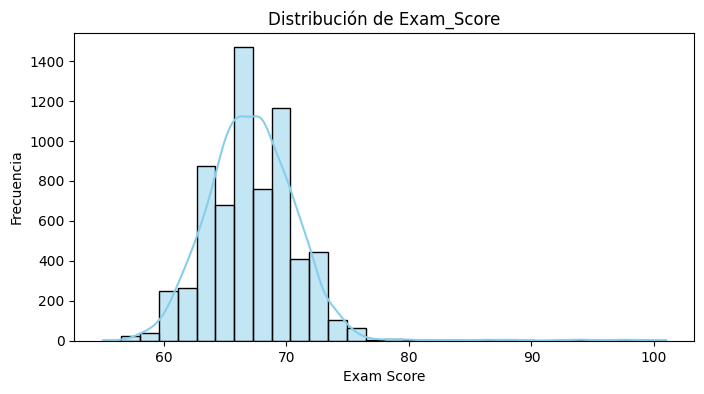

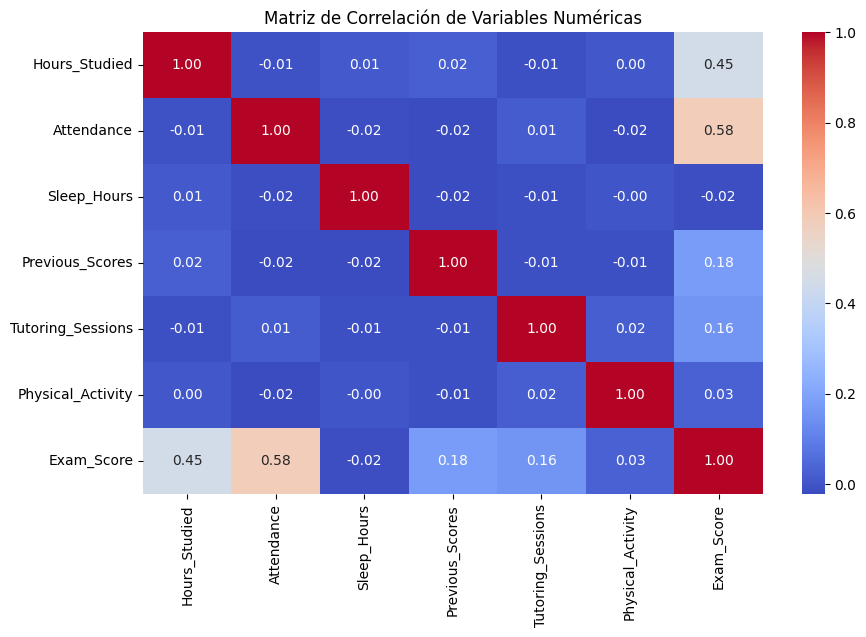

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 4))
sns.histplot(df['Exam_Score'], kde=True, bins=30, color='skyblue')
plt.title('Distribución de Exam_Score')
plt.xlabel('Exam Score')
plt.ylabel('Frecuencia')
plt.show()

plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

In [40]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

In [41]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X = df_encoded.drop(columns=['Exam_Score'])
y = df_encoded['Exam_Score']

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Set de Entrenamiento: {X_train.shape}")
print(f"Set de Prueba: {X_test.shape}")

Set de Entrenamiento: (5285, 27)
Set de Prueba: (1322, 27)


Resumir el resultado de las transformaciones mediante una comparación del estado inicial y final del dataset:

In [46]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

resumen_limpieza = pd.DataFrame({
    'Métrica de Control': [
        'Total de observaciones (filas)',
        'Total de atributos (columnas)',
        'Valores nulos detectados',
        'Filas duplicadas',
        'Variables categóricas procesadas',
        'Variables numéricas estandarizadas'
    ],
    'Antes de Procesar': [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        0,
        0
    ],
    'Después de Procesar': [
        df_encoded.shape[0],
        df_encoded.shape[1],
        df_encoded.isnull().sum().sum(),
        df_encoded.duplicated().sum(),
        len(cat_cols),
        len(numeric_cols)
    ]
})

print("=== TABLA COMPARATIVA: ANTES VS. DESPUÉS DE LA LIMPIEZA Y PREPARACIÓN ===")
display(resumen_limpieza)

=== TABLA COMPARATIVA: ANTES VS. DESPUÉS DE LA LIMPIEZA Y PREPARACIÓN ===


,Métrica de Control,Antes de Procesar,Después de Procesar
0,Total de observaciones (filas),6607,6607
1,Total de atributos (columnas),20,28
2,Valores nulos detectados,235,0
3,Filas duplicadas,0,0
4,Variables categóricas procesadas,0,13
5,Variables numéricas estandarizadas,0,7
